In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

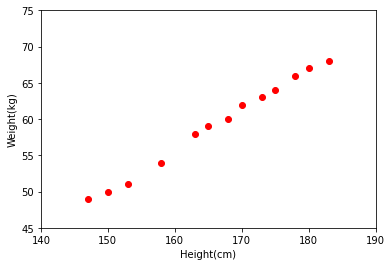

In [2]:
#Height(cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
#Weight(kg)
y = np.array([[ 49, 50, 51, 54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# Visualize data 
plt.plot(X, y, "ro")
plt.axis([140, 190, 45, 75])
plt.xlabel("Height(cm)")
plt.ylabel("Weight(kg)")
plt.show()

#### ===> (weight) = w1 * (height) + w0
### Calculate w0 and w1 base on (5) formula
    Giả nghịch đảo của ma trận A trong Python sẽ đc tính bằng numpy.linalg.pinv(A), pinv là pseudo inverse

In [3]:
#Building X bar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)
print(Xbar)

[[  1. 147.]
 [  1. 150.]
 [  1. 153.]
 [  1. 158.]
 [  1. 163.]
 [  1. 165.]
 [  1. 168.]
 [  1. 170.]
 [  1. 173.]
 [  1. 175.]
 [  1. 178.]
 [  1. 180.]
 [  1. 183.]]


In [4]:
#Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)

print("w =", w)

w = [[-33.73541021]
 [  0.55920496]]


In [5]:
#Preparing the fitting line 
w0 = w[0][0]
w1 = w[1][0]
x0 = np.linspace(145, 185, 2) #Lấy 2 số trong khoảng từ 145 đến 185
y0 = w0 + w1 * x0

print(x0)
print(y0)

[145. 185.]
[47.34930928 69.71750775]


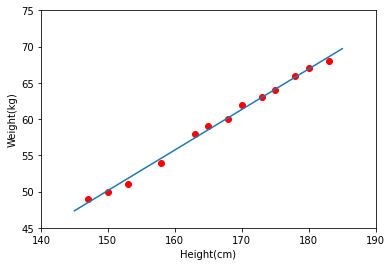

In [6]:
#Drawing the fitting line 
plt.plot(X.T, y.T, "ro") #data points
plt.plot(x0, y0) #the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel("Height(cm)")
plt.ylabel("Weight(kg)")
plt.show()

In [7]:
print( u"Predict weight of person with height 155 cm: %.2f(kg), real number: 52(kg)" % (w1 * 155 + w0) )
print( u"Predict weight of person with height 160 cm: %.2f(kg), real number: 56(kg)" % (w1 * 160 + w0) )

Predict weight of person with height 155 cm: 52.94(kg), real number: 52(kg)
Predict weight of person with height 160 cm: 55.74(kg), real number: 56(kg)


## Tìm nghiệm theo thư viện scikit-learn

In [8]:
from sklearn import datasets, linear_model

#Fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept = False) #fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

#Compare two results
print( "Solution found by scikit-learn:", regr.coef_ )
print( "Solution found by (5) formula:", w.T)

Solution found by scikit-learn: [[-33.73541021   0.55920496]]
Solution found by (5) formula: [[-33.73541021   0.55920496]]
